In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mutual_info_score
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

##### Preparing the dataset

In [2]:
# Check the data
df = pd.read_csv("course_lead_scoring_2026.csv")
df.head()


,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


In [3]:
# Check the total of missing values
df.isnull().sum()

lead_source                 148
industry                    240
employment_status           194
location                    208
annual_income               369
number_of_courses_viewed      0
interaction_count             0
lead_score                   35
converted                     0
dtype: int64

In [4]:
# Replace missing values
num_cols = df.select_dtypes(include="number").columns
cat_cols = df.select_dtypes(exclude="number").columns

df[num_cols] = df[num_cols].fillna(0.0)
df[cat_cols] = df[cat_cols].fillna("NA")

# Check the total of missing values
df.isnull().sum()

lead_source                 0
industry                    0
employment_status           0
location                    0
annual_income               0
number_of_courses_viewed    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

##### EDA

In [5]:
# Size and dtypes
df.shape                                       # number of rows and columns
df.info()                                      # dtypes and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               5000 non-null   object 
 1   industry                  5000 non-null   object 
 2   employment_status         5000 non-null   object 
 3   location                  5000 non-null   object 
 4   annual_income             5000 non-null   float64
 5   number_of_courses_viewed  5000 non-null   int64  
 6   interaction_count         5000 non-null   int64  
 7   lead_score                5000 non-null   float64
 8   converted                 5000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 351.7+ KB


In [6]:
# Statistics
df.describe()                                  # summary statistics for numerical features
df.nunique()                                   # number of unique values per feature
df.duplicated().sum()                          # number of duplicate rows
df[cat_cols].describe()                        # count, unique, top, freq for categorical features

,lead_source,industry,employment_status,location
count,5000,5000,5000,5000
unique,6,7,5,6
top,organic_search,technology,employed,north_america
freq,1251,1173,2633,1371


array([[<Axes: title={'center': 'annual_income'}>,
        <Axes: title={'center': 'number_of_courses_viewed'}>],
       [<Axes: title={'center': 'interaction_count'}>,
        <Axes: title={'center': 'lead_score'}>],
       [<Axes: title={'center': 'converted'}>, <Axes: >]], dtype=object)

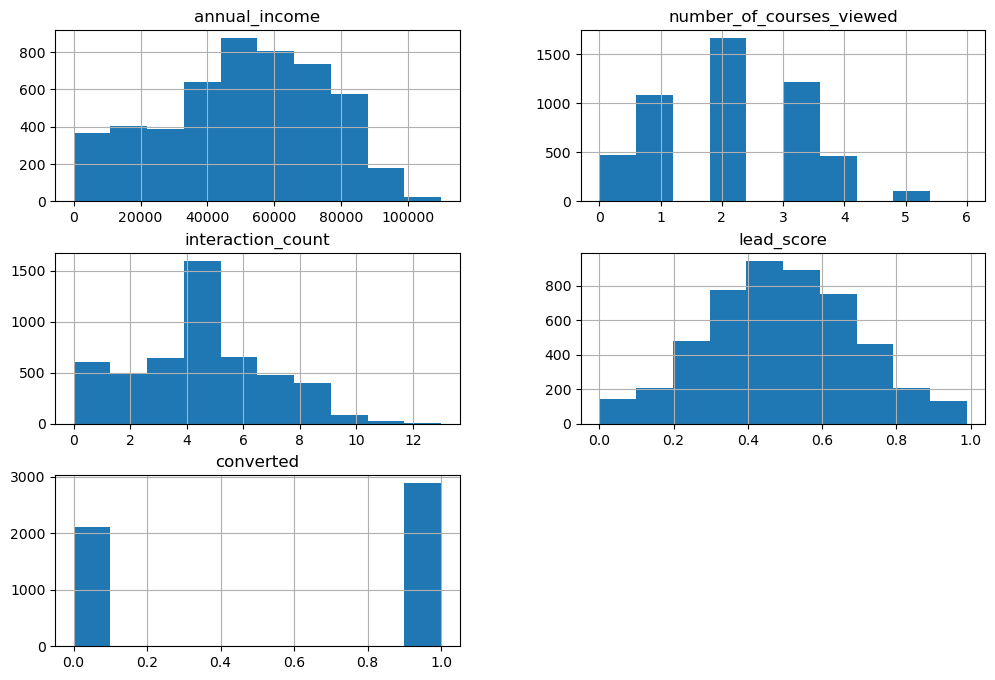

In [7]:
# Distributions
df[num_cols].hist(figsize=(12, 8))             # distributions of numerical features

##### Question 1

In [8]:
# The most frequent observation for industry
industry_mode = df['industry'].mode()

# df['industry'].value_counts()
# df['industry'].isnull().sum()   # moet 0 zijn na het invullen

industry_mode

0    technology
Name: industry, dtype: object

##### Question 2

Highest correlation: interaction_count and lead_score = 0.92


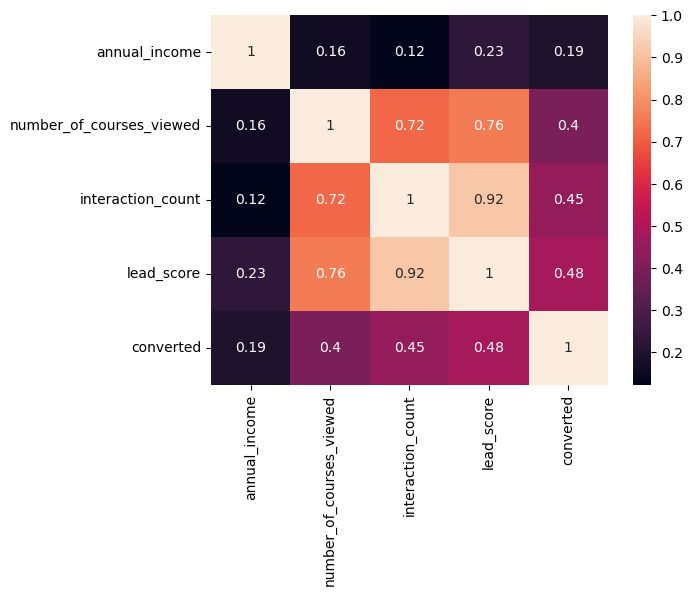

In [9]:
# Correlations between numerical features
sns.heatmap(df[num_cols].corr(), annot=True)   

corr = df[num_cols].corr()
np.fill_diagonal(corr.values, 0)   # ignore the diagonal (always 1)

a, b = corr.stack().idxmax()
print(f"Highest correlation: {a} and {b} = {corr.loc[a, b]:.2f}")

##### Split the data

In [10]:
# Split the data and save the target variable
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42)

y_train = df_train['converted'].values
y_val = df_val['converted'].values
y_test = df_test['converted'].values

del df_train['converted']
del df_val['converted']
del df_test['converted']

##### Question 3

In [11]:
# Check the mutual information for every categorical column
mi = {}
for col in cat_cols:
    mi[col] = round(mutual_info_score(df_train[col], y_train), 2)

best = max(mi, key=mi.get)   # key with the highest value
print(f"Highest MI: {best} = {mi[best]}")

Highest MI: lead_source = 0.03


##### Question 4

In [12]:
# Use one hot encoding to change the categorical variables
dv = DictVectorizer(sparse=False)

# Use fit_transform on the training set to learn the columns and convert
X_train = dv.fit_transform(df_train.to_dict(orient="records"))

# Use transform on val and test to reuse what was learned from the training set
X_val = dv.transform(df_val.to_dict(orient="records"))
X_test = dv.transform(df_test.to_dict(orient="records"))

# Check the column names created by the DictVectorizer
print(dv.get_feature_names_out())

['annual_income' 'employment_status=NA' 'employment_status=employed'
 'employment_status=self_employed' 'employment_status=student'
 'employment_status=unemployed' 'industry=NA' 'industry=education'
 'industry=finance' 'industry=healthcare' 'industry=manufacturing'
 'industry=retail' 'industry=technology' 'interaction_count' 'lead_score'
 'lead_source=NA' 'lead_source=events' 'lead_source=organic_search'
 'lead_source=paid_ads' 'lead_source=referral' 'lead_source=social_media'
 'location=NA' 'location=africa' 'location=asia' 'location=europe'
 'location=north_america' 'location=south_america'
 'number_of_courses_viewed']


In [ ]:
# Train a logistic regression on the training set
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [21]:
# Calculate the accuracy on the validation set
y_pred = model.predict(X_val)
accuracy = round(accuracy_score(y_val, y_pred), 2)

print(f"Accuracy on the validation set: {accuracy}")

# In a shorter way without an extra import
# accuracy = round(model.score(X_val, y_val), 2)

# Or in a manual way
# def sigmoid(z):
#     return 1 / (1 + np.exp(-z))

# z = model.intercept_[0] + X_val @ model.coef_[0]   # w0 + x1*w1 + x2*w2 + ...
# y_prob = sigmoid(z)                                # probability of converted = 1

# y_pred_manual = (y_prob >= 0.5).astype(int)
# print((y_pred_manual == y_pred).all())      
# print(round((y_pred_manual == y_val).mean(), 3))   

Accuracy on the validation set: 0.65


##### Question 5

In [27]:
# Use this to do some feature elimination
# Refit dv and model for each feature set: the ones above were fitted on all features
def accuracy(features):
    dv = DictVectorizer(sparse=False)
    X_tr = dv.fit_transform(df_train[features].to_dict(orient="records"))
    X_v = dv.transform(df_val[features].to_dict(orient="records"))

    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
    model.fit(X_tr, y_train)
    return model.score(X_v, y_val)

# Baseline accuracy with all features
all_features = df_train.columns.tolist()
original = accuracy(all_features)

# print(original) > 0.645

# Drop one feature at a time and compare with the baseline
diffs = {}
for f in all_features:
    features = [c for c in all_features if c != f]
    diffs[f] = original - accuracy(features)

# Sort from smallest to largest difference
options = ['lead_source', 'number_of_courses_viewed', 'interaction_count']
pd.Series(diffs)[options].sort_values()

number_of_courses_viewed    0.002
lead_source                 0.003
interaction_count           0.044
dtype: float64

##### Question 6

In [31]:
# Regularization strengths
c_values = [0.000001, 0.00001, 0.0001, 0.001]

for c in c_values:
    # Train a regularized logistic regression on the training set with C as regularization
    model = LogisticRegression(solver='liblinear', C=c, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    accuracy = round(accuracy_score(y_val, y_pred), 3)

    print(f"Accuracy on the validation set with C={c:.6f}: {accuracy}")

Accuracy on the validation set with C=0.000001: 0.598
Accuracy on the validation set with C=0.000010: 0.598
Accuracy on the validation set with C=0.000100: 0.613
Accuracy on the validation set with C=0.001000: 0.645
